In [11]:
import math
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model
import pandas as pd

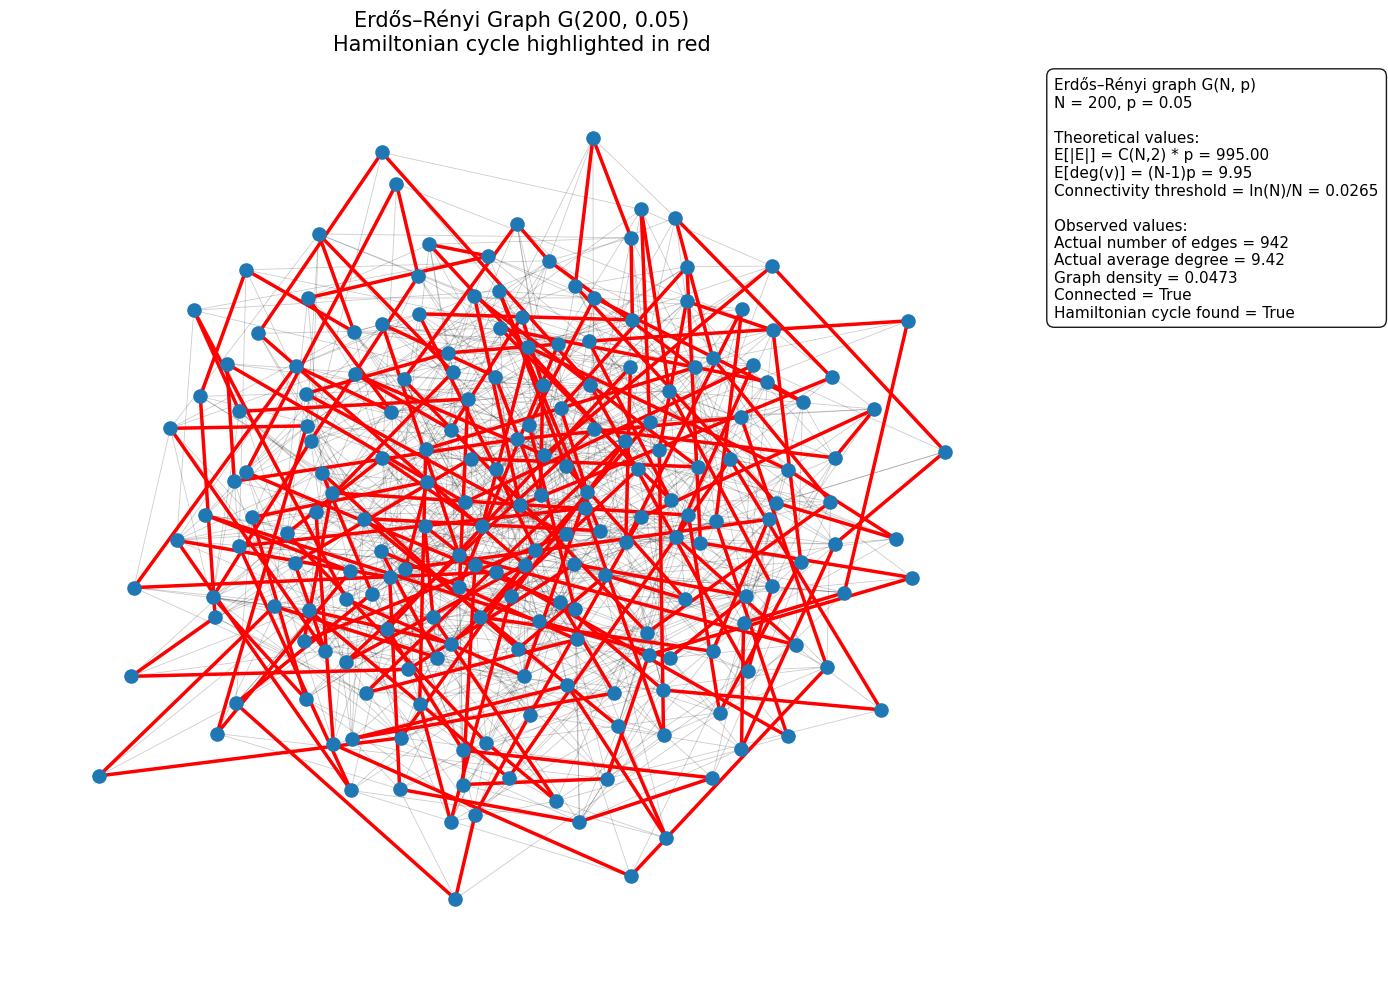

In [20]:
N = 200
p = 0.05
seed = 42
time_limit = 30

G = nx.gnp_random_graph(N, p, seed=seed)

expected_edges = math.comb(N, 2) * p
expected_degree = (N - 1) * p
connectivity_threshold = math.log(N) / N

actual_edges = G.number_of_edges()
actual_avg_degree = sum(dict(G.degree()).values()) / N
density = nx.density(G)
is_connected = nx.is_connected(G)

n = G.number_of_nodes()
nodes = list(G.nodes())
node_to_idx = {node: i for i, node in enumerate(nodes)}
idx_to_node = {i: node for i, node in enumerate(nodes)}

model = cp_model.CpModel()
arcs = []
arc_vars = {}

for u, v in G.edges():
    iu = node_to_idx[u]
    iv = node_to_idx[v]

    x_uv = model.NewBoolVar(f"x_{iu}_{iv}")
    x_vu = model.NewBoolVar(f"x_{iv}_{iu}")

    arc_vars[(iu, iv)] = x_uv
    arc_vars[(iv, iu)] = x_vu

    arcs.append((iu, iv, x_uv))
    arcs.append((iv, iu, x_vu))

model.AddCircuit(arcs)

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = time_limit
solver.parameters.num_search_workers = 8

status = solver.Solve(model)

ham_cycle = None

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    successor = {}

    for (i, j), var in arc_vars.items():
        if solver.Value(var) == 1:
            successor[i] = j

    start = 0
    cycle_idx = [start]
    current = start

    valid = True
    while True:
        nxt = successor[current]
        cycle_idx.append(nxt)
        current = nxt

        if current == start:
            break

        if len(cycle_idx) > n + 1:
            valid = False
            break

    if valid and len(cycle_idx) == n + 1 and len(set(cycle_idx[:-1])) == n:
        ham_cycle = [idx_to_node[i] for i in cycle_idx]

ham_found = ham_cycle is not None

pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(14, 10))

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.20, width=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=90)

if ham_found:
    cycle_edges = list(zip(ham_cycle[:-1], ham_cycle[1:]))
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=cycle_edges, width=2.5, edge_color="red")

info_text = (
    f"Erdős–Rényi graph G(N, p)\n"
    f"N = {N}, p = {p}\n\n"
    f"Theoretical values:\n"
    f"E[|E|] = C(N,2) * p = {expected_edges:.2f}\n"
    f"E[deg(v)] = (N-1)p = {expected_degree:.2f}\n"
    f"Connectivity threshold = ln(N)/N = {connectivity_threshold:.4f}\n\n"
    f"Observed values:\n"
    f"Actual number of edges = {actual_edges}\n"
    f"Actual average degree = {actual_avg_degree:.2f}\n"
    f"Graph density = {density:.4f}\n"
    f"Connected = {is_connected}\n"
    f"Hamiltonian cycle found = {ham_found}"
)

ax.text(
    1.02, 0.98, info_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9)
)

if ham_found:
    ax.set_title(
        "Erdős–Rényi Graph G(200, 0.05)\nHamiltonian cycle highlighted in red",
        fontsize=15
    )
else:
    ax.set_title(
        "Erdős–Rényi Graph G(200, 0.05)\nNo Hamiltonian cycle found within time limit",
        fontsize=15
    )

ax.axis("off")
plt.tight_layout()
plt.show()


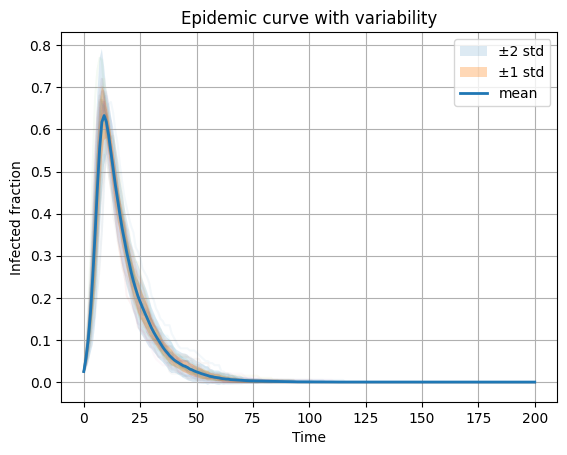

In [17]:
df = pd.read_csv(r"data\\infected_timeseries.csv")

mean = df.groupby("time")["infected_fraction"].mean()
std = df.groupby("time")["infected_fraction"].std()

for rep_id in df["replicate_id"].unique():
    subset = df[df["replicate_id"] == rep_id]
    plt.plot(subset["time"], subset["infected_fraction"], alpha=0.05)

plt.fill_between(
    mean.index,
    mean - 2*std,
    mean + 2*std,
    alpha=0.15,
    label="±2 std"
)

plt.fill_between(
    mean.index,
    mean - std,
    mean + std,
    alpha=0.3,
    label="±1 std"
)

plt.plot(mean.index, mean.values, linewidth=2, label="mean")

plt.title("Epidemic curve with variability")
plt.xlabel("Time")
plt.ylabel("Infected fraction")

plt.legend()
plt.grid(True)
plt.show()

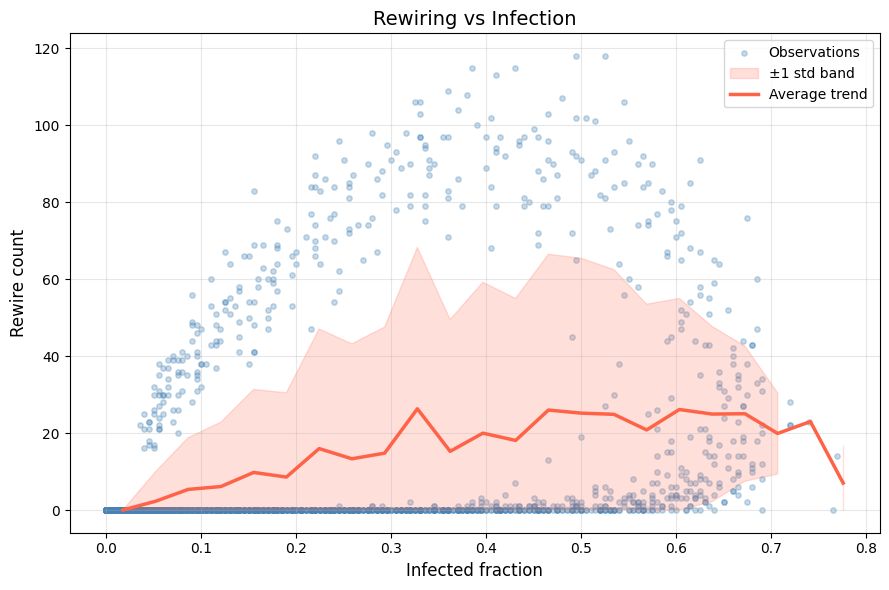

In [ ]:
infected = pd.read_csv(r"data\\infected_timeseries.csv")
rewiring = pd.read_csv(r"data\\rewiring_timeseries.csv")
df = pd.merge(infected, rewiring, on=["replicate_id", "time"])

bins = np.linspace(0, 1, 30)
df["bin"] = pd.cut(df["infected_fraction"], bins)  # no observed= here

grouped = df.groupby("bin", observed=False)["rewire_count"]
trend_mean = grouped.mean()
trend_std  = grouped.std()
bin_centers = [b.mid for b in trend_mean.index]

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df["infected_fraction"],
    df["rewire_count"],
    alpha=0.3,
    s=15,
    color="steelblue",
    label="Observations",
)

ax.fill_between(
    bin_centers,
    (trend_mean - trend_std).clip(lower=0),
    trend_mean + trend_std,
    alpha=0.2,
    color="tomato",
    label="±1 std band",
)

ax.plot(bin_centers, trend_mean, color="tomato", linewidth=2.5, label="Average trend")

ax.set_xlabel("Infected fraction", fontsize=12)
ax.set_ylabel("Rewire count", fontsize=12)
ax.set_title("Rewiring vs Infection", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()